# The World-Series-Effect — a quantitative teardown 🔬
### League-omen and city-omen Welch/permutation splits · the base-rate-corrected binomial hit-rate test · a coin-flip myth-check · an omen-timing strategy vs buy-and-hold · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). This is the Super Bowl Indicator's baseball cousin — same claim shape, same absence of a proposed mechanism, tested with the same rigor as every other study on this desk.

> ⚠️ **Data note.** ^GSPC daily close (1949-11-01 → 2026-06-30), yfinance, cached, resampled to December-close-to-December-close calendar-year returns (price-only — ^GSPC carries no dividends). **76 hardcoded World Series champions, 1950 → 2025** (75 actually played — 1994's players' strike is a named quirk, not imputed); **74 scoreable events** pair a champion with a COMPLETE next calendar year (the still-open 2025 champion has no scoreable next year yet). No survivorship on the Signal axis (^GSPC is an index, not a survivor panel). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `50410c20273a`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from world_series_effect import data, strategy as st

WS = data.ws_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    GSPC = data.load_real()
    ANN = data.annual_returns(GSPC)
    EV = st.build_events(WS, ANN)
else:
    GSPC = ANN = EV = None
print("real cache present:", HAVE_REAL, "| played World Series:", len(WS),
      "| scoreable events:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': 1950, 'end': 2025, 'n_played': 75, 'n_events': 74, 'n_al': 39, 'n_nl': 35, 'n_ny': 19, 'n_nonny': 55, 'uncond_up_pct': 73.0, 'nl_mean_bull': 11.21, 'nl_mean_bear': 7.16, 'nl_contrast': 4.05, 'nl_welch_t': 1.07, 'nl_perm_p': 0.2955, 'nl_hit': 52.7, 'nl_hit_lo': 41.5, 'nl_hit_hi': 63.7, 'nl_binom_p': 0.3675, 'nl_coin_p': 0.7275, 'ny_mean_bull': 8.02, 'ny_mean_bear': 9.43, 'ny_contrast': -1.41, 'ny_welch_t': -0.33, 'ny_perm_p': 0.7512, 'ny_hit': 39.2, 'ny_hit_lo': 28.9, 'ny_hit_hi': 50.6, 'ny_binom_p': 0.5896, 'ny_coin_p': 0.0805, 'bah_ann': 7.75, 'nl_strat_ann': 4.68, 'nl_strat_adv': -3.06, 'nl_n_held': 35, 'ny_strat_ann': 1.73, 'ny_strat_adv': -6.01, 'ny_n_held': 19, 'syn_null_mean': 0.09, 'syn_null_sd': 0.88, 'syn_null_fire': 0, 'syn_boost': 10.0, 'syn_planted_t': 3.01, 'syn_bull_mean': 17.68, 'syn_bear_mean': 5.78, 'fp_gspc': '50410c20273a'}


real cache present: True | played World Series: 75 | scoreable events: 74


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | league-omen Welch **t = 1.07** (permutation *p* = 0.2955, binomial *p* = 0.3675 vs 73.0% baseline); city-omen Welch **t = -0.33** (permutation *p* = 0.7512), wrong-signed |
| **Tradability** | `MIRAGE` | omen-timing underperforms buy-and-hold by **-3.06 pp/yr** (league) / **-6.01 pp/yr** (city) |
| **Beats a coin?** | `BUSTED` | coin-test *p* = 0.7275 (league), 0.0805 (city, hit rate 39.2% — below 50%) |

> 💡 In plain words: there's a pennant winner every year and the market goes up most years anyway; multiply those two facts together and you get exactly the noise measured below — nothing more.

## 1 · The claim, steelmanned

Let $R_{y+1}$ be the ^GSPC calendar-year simple return following World Series season $y$, and $L_y \in \{AL, NL\}$ the champion's league (known by early November of year $y$ — public well before the Jan 1 entry, zero look-ahead). The primary claim, ported from the Super Bowl Indicator's NFC/AFC mnemonic:

- **H₁ (league omen).** $E[R_{y+1} \mid L_y = NL] > E[R_{y+1} \mid L_y = AL]$, and the split is large enough to certify.

The brief's city-mythology variant, with $NY_y \in \{0,1\}$ flagging a New York franchise (Yankees/Giants/Mets/Brooklyn Dodgers) champion:

- **H₂ (city omen).** $E[R_{y+1} \mid NY_y = 1] > E[R_{y+1} \mid NY_y = 0]$.

Both claims lack any stated economic mechanism — unlike, say, this desk's [FOMC vol-crush](../../637-fomc-vol-crush/) study — so the honest prior going in is already low; the job is to measure the data anyway and report exactly how it fails.

## 2 · So what? — inference design

World Series seasons are **single, non-overlapping annual events** (the same design as [158-super-bowl](../../158-super-bowl/)), so the planned primary is a **Welch *t*** on the two-group mean-return split. Because the null hypothesis's correct reference point is the sample's own **unconditional up-rate** — not a 50% coin — the binomial hit-rate test uses $p_0 = $ that up-rate as its null, exactly the correction 158 applies to the Super Bowl Indicator. A **20,000-draw permutation test** on the two-sided mean contrast sidesteps any normality assumption at this small n, and a separate, looser **coin-flip test** ($p_0 = 0.5$) is reported purely as the grey "myth-check" third axis — never used to certify the Signal stamp.

## 3 · How we'd know — the protocol

- **Calendar.** 75 World Series actually played 1950 → 2025 (1994 cancelled by the players' strike, named and dropped), hardcoded from MLB's postseason record.
- **Tape.** ^GSPC daily close, resampled to December-to-December calendar-year returns; only COMPLETE years are ever used. As-of 2026-06-30 (last complete month) — 74 events score a champion against a complete next year.
- **Headline.** Welch *t* + a base-rate-corrected binomial hit-rate test (Wilson interval) + a 20,000-draw permutation test, run for both the league omen and the city omen.
- **Myth-check.** A separate, looser two-sided binomial test against a flat 50% coin — reported because it's the question the folklore itself would ask.
- **Execution (tradability).** One documented convention: enter at the World Series season's December 31 close, hold the following calendar year — the champion's league/city is public weeks before that date, zero look-ahead.
- **Control.** Synthetic annual-return generator with a random bull/bear flag (base rate matched to the real NL share) and a planted omen boost; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The league omen — Welch split, permutation, and the base-rate trap

NL-preceded +11.21%  vs  AL-preceded +7.16%   Welch t = +1.07   permutation p = 0.2955
hit rate 52.7%  vs  unconditional up-rate 73.0%   binomial p = 0.3675


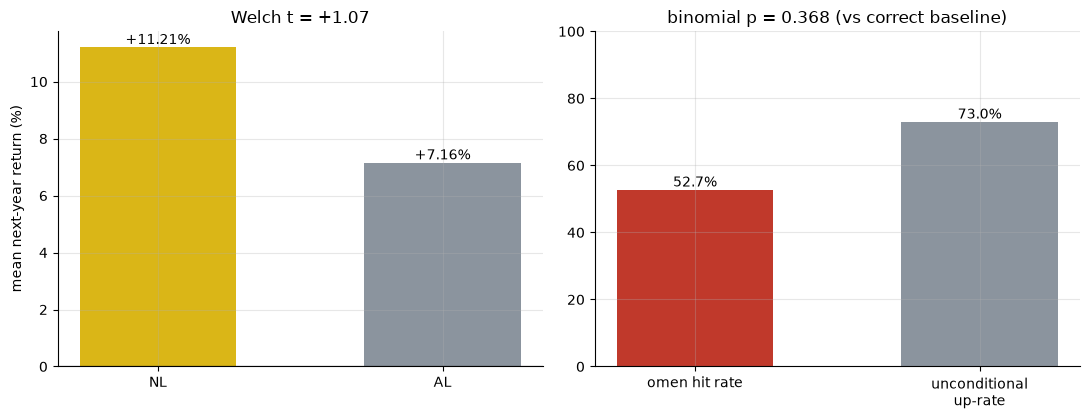

In [2]:
if HAVE_REAL:
    bull_nl = (EV['league'] == 'NL').to_numpy()
    s = st.omen_stats(EV, bull_nl)
    mb, mr, t, pp = s['mean_bull_pct'], s['mean_bear_pct'], s['welch_t'], s['perm_p']
    hit, base, bp = s['hit_rate_pct'], s['uncond_up_pct'], s['binom_p']
else:
    mb, mr, t, pp = R['nl_mean_bull'], R['nl_mean_bear'], R['nl_welch_t'], R['nl_perm_p']
    hit, base, bp = R['nl_hit'], R['uncond_up_pct'], R['nl_binom_p']
print(f"NL-preceded {mb:+.2f}%  vs  AL-preceded {mr:+.2f}%   "
      f"Welch t = {t:+.2f}   permutation p = {pp:.4f}")
print(f"hit rate {hit:.1f}%  vs  unconditional up-rate {base:.1f}%   "
      f"binomial p = {bp:.4f}")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['NL','AL'], [mb, mr], color=[AMBER, GREY], width=.55)
for i,v in enumerate([mb, mr]): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_title(f'Welch t = {t:+.2f}')
a1.set_ylabel('mean next-year return (%)')
a2.bar(['omen hit rate','unconditional\nup-rate'], [hit, base], color=[RED, GREY], width=.55)
for i,v in enumerate([hit, base]): a2.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylim(0, 100); a2.set_title(f'binomial p = {bp:.3f} (vs correct baseline)')
plt.tight_layout(); plt.show()

> 💡 In plain words: +4.0 pp looks like something until you see the *t* (1.07, bar is 2) and the permutation *p* (0.30 — chance alone reproduces this 30% of the time). Worse, the omen's own hit rate (52.7%) sits *below* the market's unconditional up-rate (73.0%) — following it would make your directional calls *less* accurate than doing nothing.

### 4b · The city omen — same design, wrong sign

NY-preceded +8.02%  vs  everyone else +9.43%   Welch t = -0.33   permutation p = 0.7512
hit rate 39.2%   binomial p = 0.5896


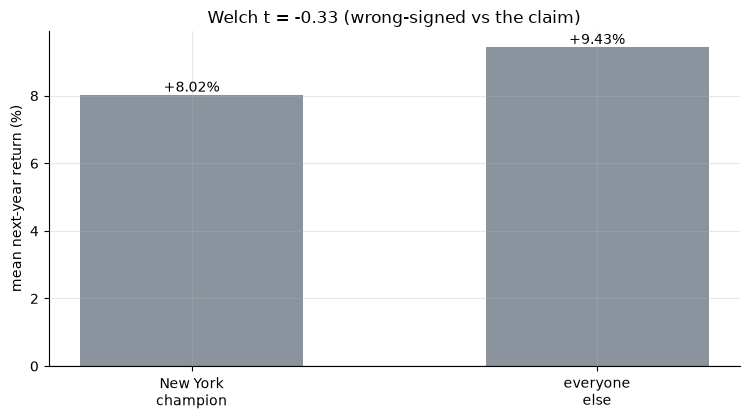

In [3]:
if HAVE_REAL:
    bull_ny = EV['is_ny'].to_numpy()
    s2 = st.omen_stats(EV, bull_ny)
    mb2, mr2 = s2['mean_bull_pct'], s2['mean_bear_pct']
    t2, pp2 = s2['welch_t'], s2['perm_p']
    hit2, bp2 = s2['hit_rate_pct'], s2['binom_p']
else:
    mb2, mr2 = R['ny_mean_bull'], R['ny_mean_bear']
    t2, pp2 = R['ny_welch_t'], R['ny_perm_p']
    hit2, bp2 = R['ny_hit'], R['ny_binom_p']
print(f"NY-preceded {mb2:+.2f}%  vs  everyone else {mr2:+.2f}%   "
      f"Welch t = {t2:+.2f}   permutation p = {pp2:.4f}")
print(f"hit rate {hit2:.1f}%   binomial p = {bp2:.4f}")
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['New York\nchampion','everyone\nelse'], [mb2, mr2], color=[GREY, GREY], width=.55)
for i,v in enumerate([mb2, mr2]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_title(f'Welch t = {t2:+.2f} (wrong-signed vs the claim)')
ax.set_ylabel('mean next-year return (%)')
plt.tight_layout(); plt.show()

> 💡 In plain words: the point estimate runs -1.41 pp — the *opposite* of the claimed direction — with *t* = -0.33 and permutation *p* = 0.75. Sixteen NY-area titles cluster across both strong- and weak-market decades; there is no pattern here, and the sign flip is a useful reminder that a plausible-sounding story ("Wall Street's hometown team") can point either way once you actually look.

### 4c · Myth-check — does either omen beat a flat coin?

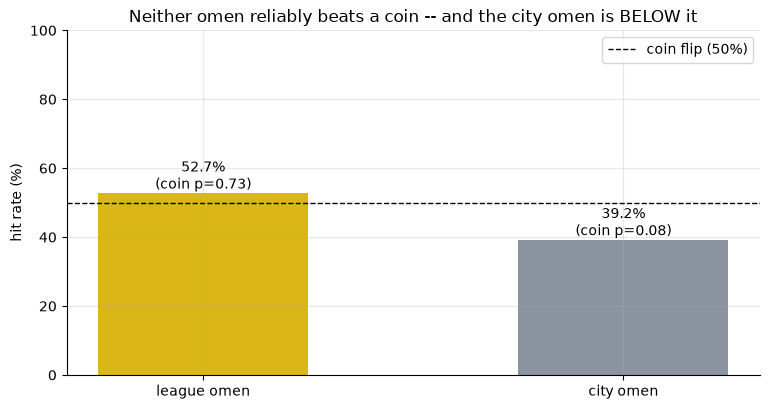

In [4]:
if HAVE_REAL:
    cp1, cp2 = s['coin_p'], s2['coin_p']
else:
    cp1, cp2 = R['nl_coin_p'], R['ny_coin_p']
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar(['league omen','city omen'], [hit, hit2], color=[AMBER, GREY], width=.5)
ax.axhline(50, ls='--', c='k', lw=1, label='coin flip (50%)')
for i,(v,p) in enumerate([(hit, cp1), (hit2, cp2)]):
    ax.annotate(f'{v:.1f}%\n(coin p={p:.2f})',(i,v),ha='center',va='bottom')
ax.set_ylim(0, 100); ax.legend()
ax.set_ylabel('hit rate (%)')
ax.set_title('Neither omen reliably beats a coin -- and the city omen is BELOW it')
plt.tight_layout(); plt.show()

> 💡 In plain words: coin-test *p* = 0.73 (league) and 0.08 (city). The city omen's hit rate (39.2%) is numerically below 50% — if anything, a New York title is a very mild *contrary* indicator here, though not a certified one either.

### 4d · Could you trade either omen?

buy-and-hold +7.75%/yr
NL-omen timing +4.68%/yr  (advantage -3.06 pp/yr)
NY-omen timing +1.73%/yr  (advantage -6.01 pp/yr)


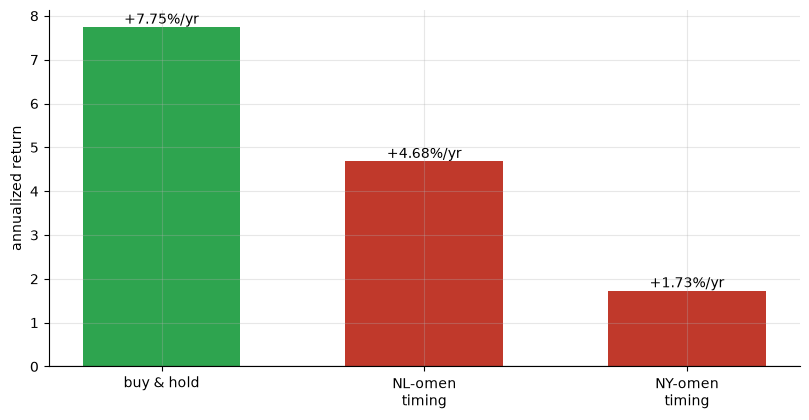

In [5]:
if HAVE_REAL:
    t1r = st.timing_strategy(EV, bull_nl); t2r = st.timing_strategy(EV, bull_ny)
    bah = t1r['bah_ann_pct']
    nl_a, nl_adv = t1r['strat_ann_pct'], t1r['ann_advantage_pct']
    ny_a, ny_adv = t2r['strat_ann_pct'], t2r['ann_advantage_pct']
else:
    bah = R['bah_ann']
    nl_a, nl_adv = R['nl_strat_ann'], R['nl_strat_adv']
    ny_a, ny_adv = R['ny_strat_ann'], R['ny_strat_adv']
print(f"buy-and-hold {bah:+.2f}%/yr")
print(f"NL-omen timing {nl_a:+.2f}%/yr  (advantage {nl_adv:+.2f} pp/yr)")
print(f"NY-omen timing {ny_a:+.2f}%/yr  (advantage {ny_adv:+.2f} pp/yr)")
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['buy & hold','NL-omen\ntiming','NY-omen\ntiming'], [bah, nl_a, ny_a],
       color=[GREEN, RED, RED], width=.6)
for i,v in enumerate([bah, nl_a, ny_a]): ax.annotate(f'{v:+.2f}%/yr',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualized return')
plt.tight_layout(); plt.show()

> 💡 In plain words: **-3.06 pp/yr** (league) and **-6.01 pp/yr** (city) of underperformance versus simply staying invested, with a single rebalance a year (transaction costs don't move this conclusion). Sitting out roughly half — or three-quarters — of a market that's up most of the time is expensive, and there's no certified signal underneath to repay it. **H(tradability) fails on both variants; Tradability = MIRAGE.**

### 4e · Faithful-engine & power control — we know the truth here

Deterministic annual-return generator: a random bull/bear flag (base rate matched to the real NL share, 35/74 ≈ 47%) with a TUNABLE planted boost added to bull-flagged years' next-year return. The null (boost = 0) is checked over **20 seeds** — never a single stream.

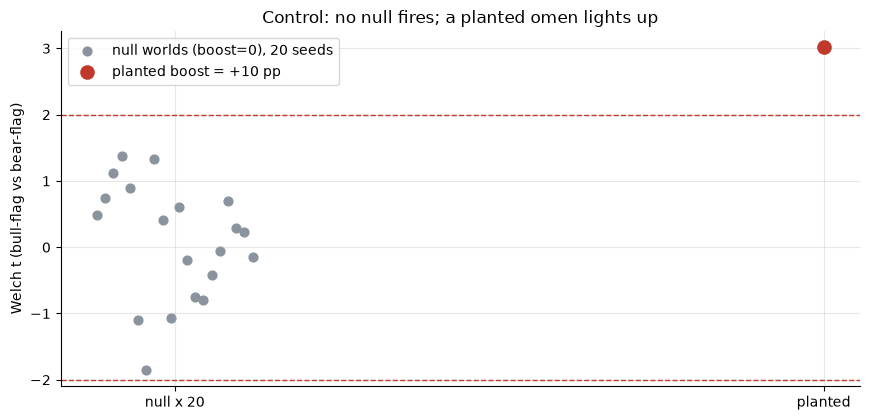

null: mean t = +0.09 (sd 0.88), |t|>=2 in 0/20 seeds  |  planted t = +3.01


In [6]:
null_ts = []
for s_ in range(20):
    syn, _ = data.synthetic_world(boost=0.0, seed=709 + s_)
    null_ts.append(st.synthetic_detect(syn)['welch_t'])
null_ts = np.asarray(null_ts)
syn, _ = data.synthetic_world(boost=10.0, seed=709)
planted_t = st.synthetic_detect(syn)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (boost=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted boost = +10 pp')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (bull-flag vs bear-flag)')
ax.set_title('Control: no null fires; a planted omen lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.09 (sd 0.88) and **never** crosses the bar; a planted +10 pp omen reads t = +3.01. The machinery is unbiased — the real-tape null result above is a genuine finding, not a blind spot in the harness. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — league-omen Welch t = **1.07** (permutation p = 0.2955, binomial p = 0.3675 vs the correct 73.0% baseline, hit rate 52.7%); city-omen Welch t = **-0.33** (permutation p = 0.7512), wrong-signed and hit rate 39.2% (below a coin). n = 74 seasons (1950 → 2024); neither variant has a proposed mechanism.
- **Tradability `MIRAGE`** — omen-timing underperforms buy-and-hold by -3.06 pp/yr (league) and -6.01 pp/yr (city); sitting out a mostly-up market has a real cost and there's no edge to offset it.
- **Beats a coin? `BUSTED`** — league-omen coin-test p = 0.7275; city-omen coin-test p = 0.0805 with a hit rate numerically below 50%. Neither omen reliably beats a flat coin flip, let alone the market's own upward bias.

## 6 · Going further

- **The whole sports-omen family collapses the same way.** Football ([158-super-bowl](../../158-super-bowl/)), the Olympics ([234-olympic-year](../../234-olympic-year/)), Eurovision ([708-eurovision-effect](../../708-eurovision-effect/)) and now baseball all fail once tested against the correct baseline with a permutation check — a reusable lesson for any calendar-labeled 'omen' claim, sporting or otherwise.
- **A natural extension** is testing every possible binary split of the champion table (division, whether the champion was a wild card, series length) with an explicit multiple-comparisons correction — the 158-super-bowl playbook — though with n ≈ 74 the power floor makes most such splits uninformative before you even start.
- **Dedup map:** [158-super-bowl](../../158-super-bowl/) (the football original, identical debunk shape), [235-world-cup-effect](../../235-world-cup-effect/) (a during-tournament drift claim, not a winner effect), [234-olympic-year](../../234-olympic-year/) (same ^GSPC/permutation machinery, a symmetric calendar marker) and [708-eurovision-effect](../../708-eurovision-effect/) (the omen family, a song contest instead of a ballgame).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*